In [12]:
using JLD2
using LensFactory
using CairoMakie

In [13]:
# Read samples
sample = jldopen("./SMACS0723/SMACS0723_sample.jld2")

# Read data
model  = sample["model"]
chains = sample["chains"]
logL   = sample["logL"]

# Reference position
RA_REF  = model.observation.reference[1];
DEC_REF = model.observation.reference[2];

In [14]:
# Let us get the cosmology out of the model
cosmo = LensModel.get_cosmology(sample)

LensFactory.Cosmology.init_cosmology{Float64}(70.0, -1.0, 0.3, 0.0, 0.7, 0.0)

In [15]:
# Get best-fit magnification at a given (RA, Dec)
best_model, _ = LensModel.get_best_model(model; mcmc_chains=chains, mcmc_logL=logL, burn_in=0.0)
dxx, dyy, dxy = LensModel.get_jacobian(best_model, 110.8246996, -73.4564175; reference=(RA_REF, DEC_REF))

(1.2201208166094104, 1.4418342189696278, -0.0036523385426767644)

In [16]:
mu_best, mu_sample = LensModel.get_magnification_image(sample, 110.8246996, -73.4564175, 1.2; burn_in=0.0, with_errors=true);

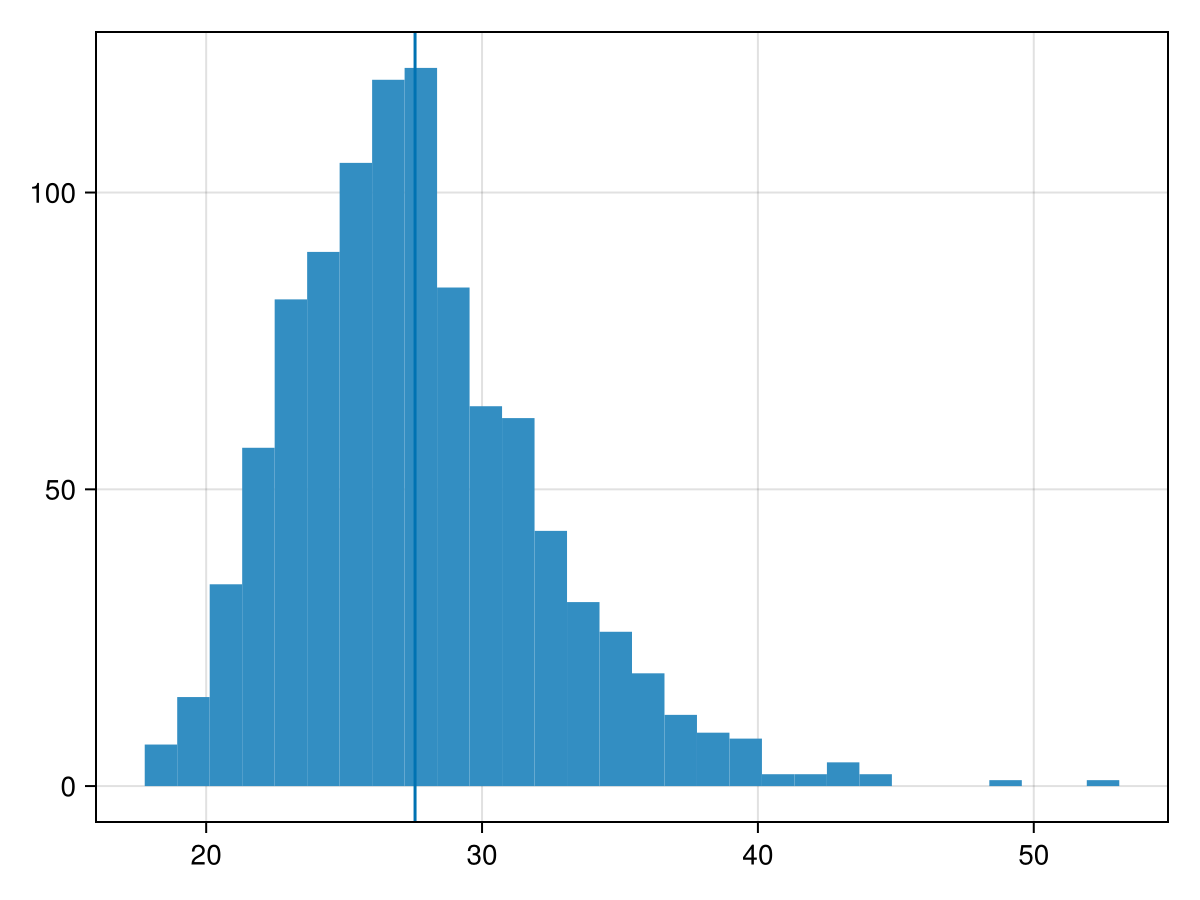

CairoMakie.Screen{IMAGE}


In [17]:
f = Figure()
hist(f[1,1], mu_sample; bins=30)
vlines!(f[1,1], mu_best)
display(f)